# **Gemini 2.0 Flash**

- [Gemini API Docs](https://ai.google.dev/gemini-api/docs/models/gemini-v2)

In [5]:
# Installation
!pip install --upgrade --quiet google-genai

In [6]:
# API Key setup
from google.colab import userdata
GEMINI_API_KEY: str = userdata.get('GEMINI_API_KEY')
if(GEMINI_API_KEY):
  print("API Key found")
else:
  print("API Key not found")

API Key found


In [7]:
# Initilize and configure the client
# Select the model
from google import genai
from google.genai import Client

client: Client = genai.Client(
    api_key=GEMINI_API_KEY,
)

model: str = "gemini-2.0-flash-exp"

## **Text Generation**

In [8]:
print([attr for attr in dir(client) if not attr.startswith('_')])

['aio', 'batches', 'caches', 'chats', 'files', 'models', 'tunings', 'vertexai']


In [9]:
print([attr for attr in dir(client.models) if not attr.startswith('_')])

['api_client', 'compute_tokens', 'count_tokens', 'delete', 'edit_image', 'embed_content', 'generate_content', 'generate_content_stream', 'generate_image', 'get', 'list', 'update', 'upscale_image']


In [10]:
from google.genai.types import GenerateContentResponse
from IPython.display import display, Markdown

response: GenerateContentResponse = client.models.generate_content(
    model=model,
    contents='How does AI work?'
)

In [11]:
display(response)

GenerateContentResponse(candidates=[Candidate(content=Content(parts=[Part(video_metadata=None, thought=None, code_execution_result=None, executable_code=None, file_data=None, function_call=None, function_response=None, inline_data=None, text='Okay, let\'s break down how AI works! It\'s a vast field, so we\'ll try to keep it clear and concise. Essentially, AI aims to make computers think and act like humans (or sometimes even better) at specific tasks. It does this through various techniques, which we can group into a few key areas:\n\n**1. The Core Concept: Learning from Data**\n\nAt its heart, most modern AI relies on the idea of **machine learning (ML)**. Instead of being explicitly programmed with rules, AI systems learn patterns and relationships from data. Think of it like teaching a child by showing them examples rather than explaining every single rule.\n\n**2. Key Techniques in AI (and how they relate to Machine Learning):**\n\n* **Machine Learning (ML):** This is the foundatio

In [12]:
display(Markdown(response.text))

Okay, let's break down how AI works! It's a vast field, so we'll try to keep it clear and concise. Essentially, AI aims to make computers think and act like humans (or sometimes even better) at specific tasks. It does this through various techniques, which we can group into a few key areas:

**1. The Core Concept: Learning from Data**

At its heart, most modern AI relies on the idea of **machine learning (ML)**. Instead of being explicitly programmed with rules, AI systems learn patterns and relationships from data. Think of it like teaching a child by showing them examples rather than explaining every single rule.

**2. Key Techniques in AI (and how they relate to Machine Learning):**

* **Machine Learning (ML):** This is the foundation of most current AI. It involves training algorithms (sets of rules or instructions) on large datasets to identify patterns and make predictions.
    * **Supervised Learning:** Like having a teacher. You provide the algorithm with labeled data (input-output pairs). For example, showing it pictures of cats and dogs labeled as "cat" or "dog." The algorithm learns to predict the correct label for new, unseen images.
    * **Unsupervised Learning:** Like exploring on your own. You provide the algorithm with unlabeled data and let it find patterns and structure on its own. For example, grouping similar customer behaviors without knowing what those groups represent beforehand.
    * **Reinforcement Learning:** Like learning through trial and error. The algorithm learns through interacting with an environment and receiving rewards or penalties based on its actions. This is often used in games and robotics.

* **Deep Learning (DL):** A subset of machine learning that uses **artificial neural networks (ANNs)** with multiple layers (hence "deep"). These layers process data in a hierarchical way, allowing for more complex patterns and representations to be learned. Deep learning is particularly good for image and speech recognition, natural language processing, and other complex tasks.

* **Artificial Neural Networks (ANNs):** Inspired by the structure of the human brain, these networks consist of interconnected nodes (neurons) that process and transmit information. They learn by adjusting the strength of these connections.

* **Natural Language Processing (NLP):** Focuses on enabling computers to understand, interpret, and generate human language. This involves tasks like text analysis, machine translation, sentiment analysis, and chatbot creation.

* **Computer Vision (CV):** Allows computers to "see" and interpret images and videos. This involves tasks like object recognition, facial recognition, image segmentation, and more.

**3. The General Process (Simplified):**

Here's a highly simplified overview of how many AI systems are developed and deployed:

1. **Data Collection:** Gathering a large amount of relevant data for training. This is crucial as the quality and quantity of data directly impact the AI's performance.
2. **Data Preprocessing:** Cleaning and preparing the data for training. This might involve handling missing values, converting data types, or normalizing the data.
3. **Model Selection:** Choosing an appropriate algorithm or model based on the task at hand.
4. **Training:** Feeding the preprocessed data into the chosen model. The model adjusts its internal parameters to learn the underlying patterns in the data.
5. **Validation and Testing:** Evaluating the performance of the trained model on data that it has not seen before. This ensures the model generalizes well to new situations.
6. **Deployment:** Putting the trained model into use, either as a standalone application or as part of a larger system.
7. **Monitoring and Improvement:** Continuously monitoring the performance of the deployed model and retraining it periodically to maintain its accuracy and adapt to changes.

**Analogy:**

Imagine teaching a child to recognize different fruits.

* **Data:** You show the child many pictures of apples, bananas, oranges, etc. (The data is the pictures).
* **ML Algorithm:** The child's brain is the algorithm, trying to learn what makes an apple different from a banana.
* **Training:** The more pictures you show, the better the child gets at identifying fruits (The training process).
* **Prediction:** You show a new picture and ask the child, "What is this?" (The prediction).

**Important Considerations:**

* **AI is not magic:** It relies on data and algorithms, and its capabilities are limited by the data it is trained on.
* **Bias:** If the training data is biased, the AI can perpetuate and even amplify those biases. This is a major ethical concern.
* **Explainability:** Understanding how AI systems make decisions is often difficult, particularly with complex models like deep neural networks. This lack of "explainability" can make it hard to trust AI systems in critical applications.
* **Constant evolution:** The field of AI is rapidly evolving, and new techniques and approaches are constantly being developed.

**In Conclusion:**

AI works by using powerful computational techniques to learn from vast amounts of data and make intelligent decisions, predictions, and actions. It's a complex and evolving field, but this overview provides a basic understanding of its core principles.

Do you have any specific aspects of AI that you'd like to explore further? Perhaps a particular type of machine learning, a specific application of AI, or ethical concerns related to the technology? Let me know!


## **Count Tokens**

In [13]:
from google.genai.types import CountTokensResponse
result: CountTokensResponse = client.models.count_tokens(
    model=model,
    contents="What's the highest mountain in Africa?",
)

print(result)

total_tokens=10 cached_content_token_count=None


## **Multimodal Prompts**

In [14]:
!curl -o image1.jpg "https://images.pexels.com/photos/36487/above-adventure-aerial-air.jpg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 42895  100 42895    0     0   210k      0 --:--:-- --:--:-- --:--:--  211k


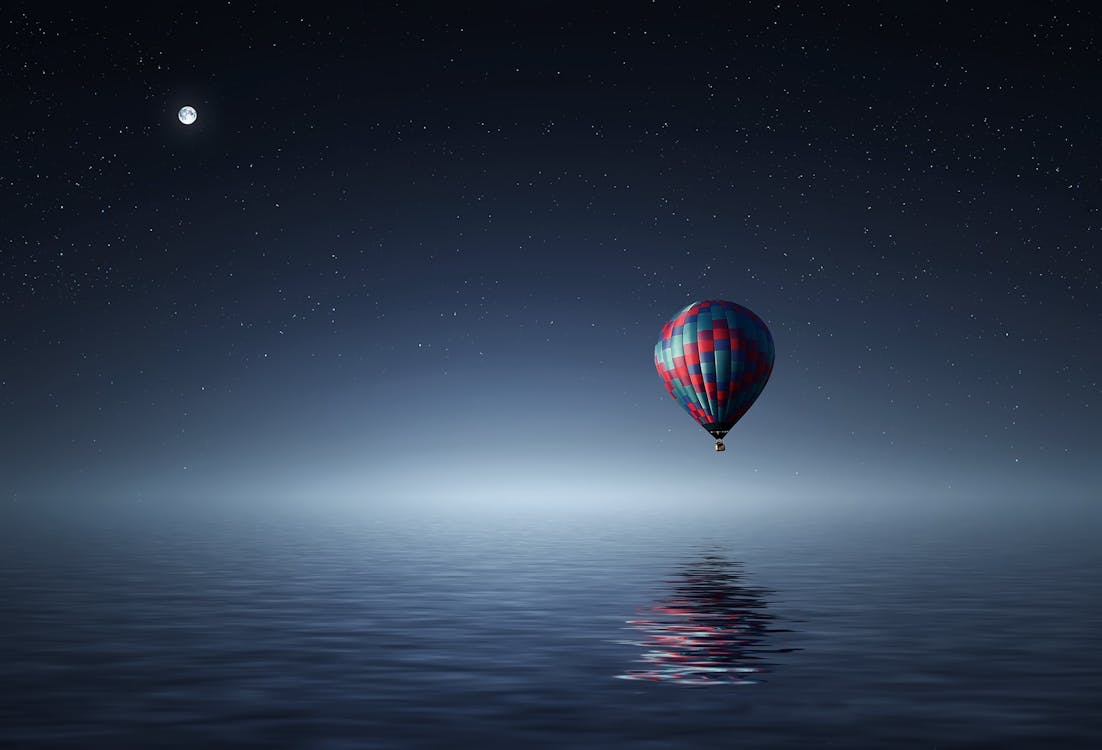

In [15]:
# Display the downloaded image
import PIL.Image
img = PIL.Image.open('image1.jpg')
display(img)

In [16]:
# Write a prompt and store it in some variable
prompt = """This image contains a sketch of a potential product along with some notes.
Given the product sketch, describe the product as thoroughly as possible based on what you
see in the image, making sure to note all of the product features. Return output in json format:
{description: description, features: [feature1, feature2, feature3, etc]}"""

In [17]:
response: GenerateContentResponse = client.models.generate_content(
    model=model,
    contents=[img,prompt]
)
display(Markdown(response.text))

```json
{
"description": "The image depicts a serene and surreal scene featuring a hot air balloon floating above a calm body of water at night. The night sky is filled with stars and a crescent moon, creating a magical atmosphere. The hot air balloon is a focal point, rendered in a vibrant mix of blue and red. The water reflects the balloon, adding depth to the image. The image seems to be an illustration or a digitally rendered photograph with a focus on atmospheric effect and visual harmony.",
  "features": [
    "Hot air balloon",
    "Water reflection",
    "Starry night sky",
    "Crescent moon",
    "Calm water",
    "Atmospheric perspective",
    "Vivid color scheme"
  ]
}
```

## **Have a Chat**

By default, a generative AI model is **stateless**—it does not retain any memory of previous interactions. This means it cannot recall information or context from earlier messages in the conversation unless explicitly provided.


In [30]:
response: GenerateContentResponse = client.models.generate_content(
    model=model,
    contents='Hye, My name is Tayyab'
)
display(Markdown(response.text))

Hi Tayyab, it's nice to meet you! I'm a large language model, and I'm here to help with anything you might need. How can I help you today?


In [31]:
response: GenerateContentResponse = client.models.generate_content(
    model=model,
    contents='Hye, What is my name'
)
display(Markdown(response.text))

Unfortunately, I don't know your name. I am an AI and do not have access to your personal information. You are the one who knows your name! 

If you'd like, you can tell me your name, and I'll be happy to use it when we chat. 😊


The Gemini API enables you to have freeform conversations across multiple turns.

In [33]:
from google.genai.chats import Chat

# Initiate a chat
chat: Chat = client.chats.create(
    model=model
)

# Send chat a message
response: GenerateContentResponse = chat.send_message("Hye, My name is Tayyab")
Markdown(response.text)

Hi Tayyab, it's nice to meet you! How can I help you today?


In [35]:
response: GenerateContentResponse = chat.send_message("What is my name?")
Markdown(response.text)

Your name is Tayyab. I remember! 😊


## **Configure model parameters**

In [22]:
from google.genai.types import GenerateContentConfig

response: GenerateContentResponse = client.models.generate_content(
    model=model,
    contents = "Tell me how the internet works, but pretend I'm a puppy who only understands squeaky toys.",
    config = GenerateContentConfig(
        temperature=0.4,
        top_p=0.95,
        candidate_count=2,
        max_output_tokens=100
    )
)

display(response)

GenerateContentResponse(candidates=[Candidate(content=Content(parts=[Part(video_metadata=None, thought=None, code_execution_result=None, executable_code=None, file_data=None, function_call=None, function_response=None, inline_data=None, text="Okay, little squeaky friend! Let's talk about the internet! Imagine a HUGE, HUGE playground, bigger than any park you've ever seen!\n\n**The Playground (The Internet):** This playground is made of lots and lots of tunnels, like the ones you love to crawl through! These tunnels are made of special wires and radio waves, like invisible squeaky toys that carry messages.\n\n**Your Squeaky Toy (Your Computer/Phone):** You have your favorite sque")], role='model'), citation_metadata=None, finish_message=None, token_count=None, avg_logprobs=-0.41999342947295215, finish_reason='MAX_TOKENS', grounding_metadata=None, index=None, logprobs_result=None, safety_ratings=[SafetyRating(blocked=None, category='HARM_CATEGORY_HATE_SPEECH', probability='NEGLIGIBLE', p

# **Video understanding**

In [23]:
# Load sample images
!wget https://storage.googleapis.com/generativeai-downloads/videos/Pottery.mp4 -O Pottery.mp4 -q

In [24]:
# Upload all the videos using the File API.
# You can find more details about how to use it in the Get Started notebook.
# This can take a couple of minutes as the videos will need to be processed and tokenized.

import time

def upload_video(video_file_name):
  video_file = client.files.upload(path=video_file_name)
  while video_file.state == "PROCESSING":
      print('Waiting for video to be processed.')
      time.sleep(10)
      video_file = client.files.get(name=video_file.name or "")

  if video_file.state == "FAILED":
    raise ValueError(video_file.state)
  print(f'Video processing complete: ' + (video_file.uri or ""))

  return video_file

pottery_video = upload_video('Pottery.mp4')

Waiting for video to be processed.
Video processing complete: https://generativelanguage.googleapis.com/v1beta/files/yu4k8k61mj7n


In [25]:
from google.genai.types import Content, Part
prompt = """For each scene in this video,
            generate captions that describe the scene along with any spoken text placed in quotation marks.
            Place each caption into an object with the timecode of the caption in the video.
         """

video = pottery_video

response = client.models.generate_content(
    model=model,
    contents=[
        Content(
            role="user",
            parts=[
                Part.from_uri(
                    file_uri=video.uri or "",
                    mime_type=video.mime_type or ""),
                ]),
        prompt,
    ]
)

Markdown(response.text)

```json
[
  {
    "timecode": "00:00",
    "caption": "A variety of pottery pieces are displayed on a light brown surface. To the left, there is a stack of eight tumblers and two tumblers laying next to them. In the center are two small bowls, with a piece of paper showing the price and description next to it. To the right are three medium-sized bowls, and another small white paper is present with its description and price. Two small tiles with glaze samples are present."
  }
]
```

## **Search as a tool**

In [26]:
from google import genai
client = genai.Client(
    api_key=GEMINI_API_KEY,
    http_options= {'api_version': 'v1alpha'}
  )
MODEL = "gemini-2.0-flash-exp"

In [27]:
import asyncio
import base64
import contextlib
import datetime
import os
import json
import wave
import itertools

from IPython.display import display, Audio

from google import genai
from google.genai import types

async def async_enumerate(it):
  n = 0
  async for item in it:
    yield n, item
    n +=1

In [28]:

@contextlib.contextmanager
def wave_file(filename, channels=1, rate=24000, sample_width=2):
    with wave.open(filename, "wb") as wf:
        wf.setnchannels(channels)
        wf.setsampwidth(sample_width)
        wf.setframerate(rate)
        yield wf


In [29]:
config={
    "generation_config": {"response_modalities": ["AUDIO"]}}

async with client.aio.live.connect(model=MODEL, config=config) as session:
  file_name = 'audio.wav'
  with wave_file(file_name) as wav:
    message = "Hello? Gemini are you there?"
    print("> ", message, "\n")
    await session.send(message, end_of_turn=True)

    turn = session.receive()
    async for n,response in async_enumerate(turn):
      if response.data is not None:
        wav.writeframes(response.data)

        if n==0:
          print(response.server_content.model_turn.parts[0].inline_data.mime_type)
        print('.', end='')


display(Audio(file_name, autoplay=True))

>  Hello? Gemini are you there? 

audio/pcm;rate=24000
..............

---